In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from src.data import ICGLCEAESDataset, EndoscapesSeg201CBDDataset
from src.data.viz import show_camma_frame_annotations
from pathlib import Path
from argparse import Namespace
from matplotlib import pyplot as plt

from infer_lora import *

In [ ]:
dataset = EndoscapesSeg201CBDDataset(split='test')

In [ ]:
frame = dataset[10]

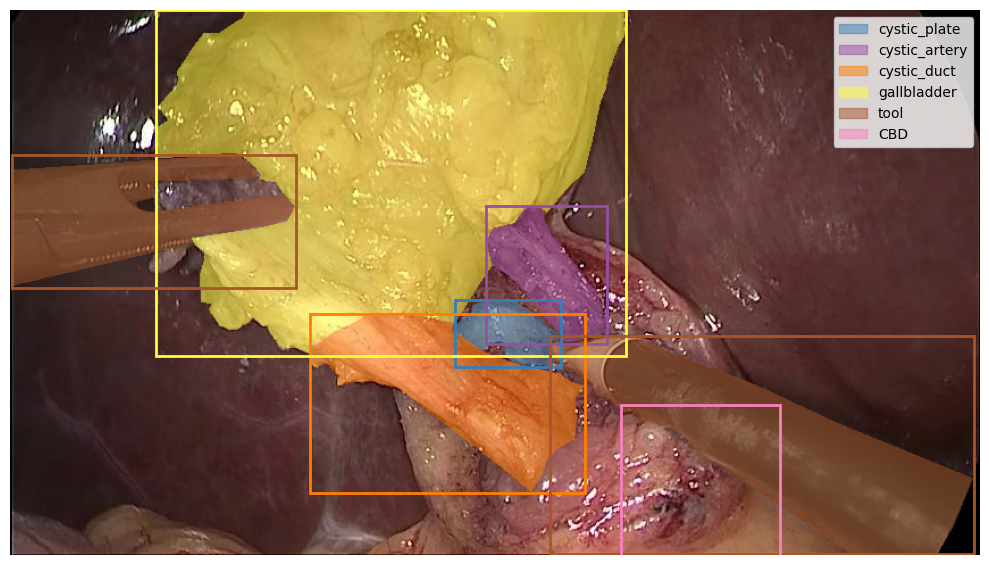

In [ ]:
fig, ax = show_camma_frame_annotations(
    frame,
    annotation_types=('bbox', 'mask'),
    bbox_anchor="topleft",
    category_id_to_name=dataset.context.category_id_to_name,)
plt.show()

In [ ]:
args = Namespace(
    config='runs/endoscapes_all_but_cbd/2026-03-30-13-50/run_1/endoscapes_lora.yaml',
    prompt=[['cystic_plate'], ['calot_triangle'], ['cystic_artery'], ['cystic_duct'],
            ['gallbladder'], ['tool'],],
    weights=None,
    device=None,
    resolution=1008,
    threshold=0.7,
    nms_iou=0.5,
    max_detections=100,
)

In [30]:
with open(args.config, "r") as handle:
    config = yaml.safe_load(handle)

model_config = config.get("model", {})
evaluation_config = config.get("evaluation", {})
training_config = config.get("training", {})
lora_config = config.get("lora", {})
prompts = flatten_prompts(args.prompt)
weights_path = resolve_weights_path(config, args.weights)
device = resolve_device(config, args.device)

In [31]:
if not weights_path.exists():
    raise FileNotFoundError(f"LoRA weights not found: {weights_path}")
if model_config.get("checkpoint_path") is None and not bool(model_config.get("load_from_hf", True)):
    raise ValueError("Config must set model.checkpoint_path or model.load_from_hf=true for inference.")

model = build_sam3_image_model(
    checkpoint_path=model_config.get("checkpoint_path"),
    device=device.type,
    eval_mode=True,
    compile=bool(config.get("hardware", {}).get("use_compile", False)),
    bpe_path=model_config.get("bpe_path"),
    load_from_HF=bool(model_config.get("load_from_hf", True)),
)
lora_cfg = build_lora_config(lora_config)
model = apply_lora_to_model(model, lora_cfg)
load_lora_weights(model, str(weights_path), expected_config=lora_cfg)
model.to(device)
_ = model.eval()

Loaded /home2020/home/miv/vedrenne/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/sam3.pt with partial key coverage:
missing_keys=[]
unexpected_keys=['backbone.vision_backbone.sam2_convs.0.dconv_2x2_0.weight', 'backbone.vision_backbone.sam2_convs.0.dconv_2x2_0.bias', 'backbone.vision_backbone.sam2_convs.0.dconv_2x2_1.weight', 'backbone.vision_backbone.sam2_convs.0.dconv_2x2_1.bias', 'backbone.vision_backbone.sam2_convs.0.conv_1x1.weight', 'backbone.vision_backbone.sam2_convs.0.conv_1x1.bias', 'backbone.vision_backbone.sam2_convs.0.conv_3x3.weight', 'backbone.vision_backbone.sam2_convs.0.conv_3x3.bias', 'backbone.vision_backbone.sam2_convs.1.dconv_2x2.weight', 'backbone.vision_backbone.sam2_convs.1.dconv_2x2.bias', 'backbone.vision_backbone.sam2_convs.1.conv_1x1.weight', 'backbone.vision_backbone.sam2_convs.1.conv_1x1.bias', 'backbone.vision_backbone.sam2_convs.1.conv_3x3.weight', 'backbone.vision_backbone.sam2_convs.1.conv_3x3.bias', 'b

In [32]:
image_path = dataset.context.split_dir / 'images' / frame.metadata['file_name']
image = PILImage.open(image_path).convert("RGB")
orig_w, orig_h = image.size
image_tensor = preprocess_image(image, args.resolution)
datapoint = build_inference_datapoint(image_tensor, prompts, (orig_h, orig_w), args.resolution)
batch = collate_fn_api([datapoint], dict_key="input", with_seg_masks=False)
input_batch = move_to_device(batch["input"], device)

In [33]:
with torch.no_grad():
    with autocast_context(device, training_config):
        outputs_list = model(input_batch)

with SAM3Output.iteration_mode(
    outputs_list,
    iter_mode=SAM3Output.IterMode.ALL_STEPS_PER_STAGE,
) as outputs_iter:
    final_outputs = list(outputs_iter)[-1][-1]

In [35]:
threshold = (
    float(args.threshold)
    if args.threshold is not None
    else float(evaluation_config.get("prob_threshold", 0.5))
)
nms_iou = (
    float(args.nms_iou)
    if args.nms_iou is not None
    else float(evaluation_config.get("nms_iou", 0.5))
)
max_detections = int(
    args.max_detections
    if args.max_detections is not None
    else evaluation_config.get("max_detections", 100)
)

predictions = []
for index, prompt in enumerate(prompts):
    presence_logit = None
    if "presence_logit_dec" in final_outputs:
        presence_logit = final_outputs["presence_logit_dec"][index]
    masks, scores, boxes = filter_predictions(
        pred_logits=final_outputs["pred_logits"][index],
        pred_masks=final_outputs["pred_masks"][index],
        pred_boxes=final_outputs["pred_boxes"][index],
        presence_logit=presence_logit,
        prob_threshold=threshold,
        nms_iou_threshold=nms_iou,
        max_detections=max_detections,
    )

    detections = []
    for mask_tensor, score, box_tensor in zip(masks, scores, boxes):
        detection = build_detection(mask_tensor, score, box_tensor, orig_h=orig_h, orig_w=orig_w)
        if detection is None:
            continue
        detections.append(detection)

    predictions.append(
        {
            "prompt": prompt,
            "color": COLOR_CYCLE[index % len(COLOR_CYCLE)],
            "detections": detections,
        }
    )

In [36]:
preds = render_overlay(image, predictions, alpha=80, save=False)

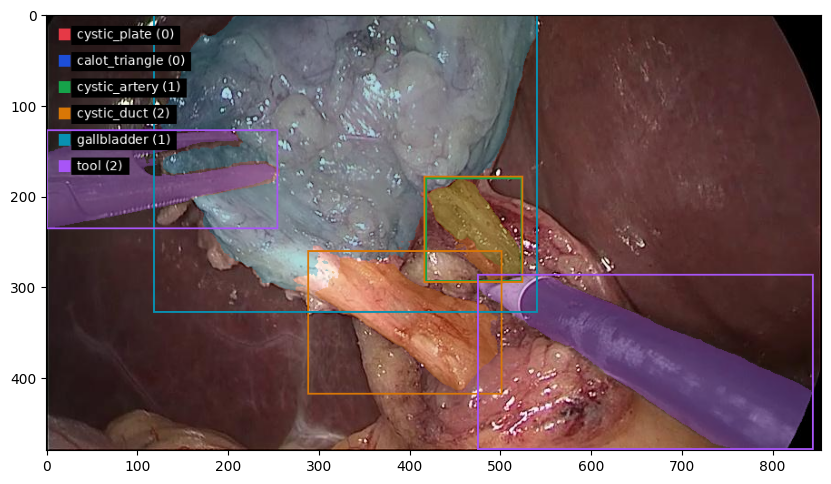

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(preds)
plt.show()